# 3. Classification (Predicting Popularity Category)

# Imports

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config, svm
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, \
    precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate

from xgboost import XGBClassifier

# Data Preparation

In this section, the dataset is imported and any null or extreme values are removed.

In [251]:
df = pd.read_csv('tracks2026.csv')
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [252]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


In [253]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
popularity,40,2.00
danceability,40,2.00
energy,40,2.00
loudness,39,1.95
tempo,40,2.00


This line removes the rows with a loudness value of 80,000. These rows also contained the null values, so those are taken care of too.

In [254]:
# This also happens to deal with the null values
df = df[df['loudness'] < 0]

In [255]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %


Here we calculate m, the median popularity.

In [256]:
median_popularity = df['popularity'].median()
median_popularity

np.float64(45.0)

The binary popularity classes are created here. It takes every popularity value and adds a 0 to the list if the value is below m, and a 1 otherwise.

In [257]:
popularity_binary = [0 if x <= median_popularity else 1 for x in df['popularity']]
popularity_binary

[0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,


The list of 0s and 1s is then inserted into the dataset.

In [258]:
df.insert(2, 'popularity_binary', popularity_binary)
df

,track_id,popularity,popularity_binary,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,1,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,1,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,1,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,1,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


Here we define the input variables for our models. These will be every column except track_id, popularity_binary (our target variable) and popularity.

In [259]:
X = df.drop(['track_id', 'popularity_binary', 'popularity'], axis=1)
X

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


Next we define the target, which is our popularity_binary variable.

In [260]:
y = df['popularity_binary']
y

0       0
1       1
2       1
3       0
4       0
       ..
1995    0
1996    1
1997    0
1998    1
1999    0
Name: popularity_binary, Length: 1960, dtype: int64

This cell defines our preprocessing pipeline. We use a power transform for the variables that have skewed distributions or outliers, specifically Yeo-Johnson transformation which allows for the negative loudness values.

The categorical variables are one-hot encoded to convert them to numeric values the models can be trained on.

Any remaining variables (just tempo in this case) are scaled using scikit-learn's StandardScaler.

In [261]:
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('power', PowerTransformer(method='yeo-johnson'), [ # Handles skewed distributions, allowing for zeros
            'instrumentalness', 'loudness', 'duration_ms', 'danceability', 'energy', 'speechiness', 'acousticness', 'liveness', 'valence'
        ]),
        ('categorical', OneHotEncoder(drop='first', sparse_output=False), ['track_genre', 'explicit', 'time_signature', 'key', 'mode'])
    ],
    remainder=StandardScaler()
).set_output(transform='pandas')

In [262]:
X_transformed = preprocess_pipeline.fit_transform(X)
X_transformed

,power__instrumentalness,power__loudness,power__duration_ms,power__danceability,power__energy,power__speechiness,power__acousticness,power__liveness,power__valence,categorical__track_genre_indie-pop,...,categorical__key_4,categorical__key_5,categorical__key_6,categorical__key_7,categorical__key_8,categorical__key_9,categorical__key_10,categorical__key_11,categorical__mode_1,remainder__tempo
0,-0.439324,1.555711,-0.159410,-0.284280,-0.483774,-1.225791,0.623572,0.171885,0.023083,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.840062
1,-0.436642,1.005534,-0.056748,1.034823,-0.171527,-0.039662,-0.596877,-0.070725,1.085435,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.700520
2,-0.438092,-0.665655,0.849065,1.227259,-0.176842,-1.002047,0.193681,1.345596,1.579300,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.065867
3,-0.439324,1.542668,-0.385924,-0.467960,1.065211,1.761483,-0.959026,1.101873,0.753299,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.019915
4,-0.437539,0.136106,1.166943,0.451911,0.379018,-0.432384,0.149005,-1.656134,-0.159191,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.345766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-0.439324,1.813407,0.906621,1.200754,1.633083,0.205253,-0.345341,1.006114,1.755632,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.473812
1996,2.797931,-0.492332,0.205051,0.153790,-0.085977,-0.946208,-0.237246,-0.749410,-0.342668,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.176693
1997,-0.439324,0.197806,-1.023224,-0.746234,0.609844,-0.148078,-0.854740,-0.460792,0.153767,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.041723
1998,-0.439324,0.220998,-2.115766,1.737525,-0.694325,1.979208,-0.173041,0.835106,1.077276,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.047551


Finally, the dataset is split into training and testing sets. 80% is used for training while the remaining 20% will be used for testing.

In [263]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# Model Training

We will use stratified k-fold cross-validation to ensure that each of the 10 folds keeps the same proportion of popular and unpopular tracks as the original dataset. We also choose the scoring metrics we will use to evaluate the models here.

In [264]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'Accuracy': 'accuracy',
    'F1-score': 'f1',
    'Precision': 'precision',
    'Recall': 'recall',
    'ROC_AUC': 'roc_auc',
    'AP': 'average_precision'
}

## SVM

The first model we train will be a support vector machine. This was chosen because it is an effective algorithm for high-dimensional datasets, like here where we have many one-hot encoded categorical variables. We create a new pipeline for it, starting with the preprocessing pipeline from earlier.

In [265]:
pipe_svm = Pipeline(steps=[('preprocess', preprocess_pipeline), ('svm', svm.SVC(probability=True))])

In [266]:
set_config(display='diagram')
pipe_svm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",StandardScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

Here we fit the train the model on the data using the F1-score to judge its ability throughout training. GridSearchCV is used to test how the model performs with different values set for the hyperparameters:
| Hyperparameter | Values Tested | Best Value |
| ---- | ---- | ---- |
| C | 0.1 - 10 | 10 |
| gamma | 0.01 - 1 | 1 |
| kernel | rbf, linear, poly | rbf |

Finally, we save the best parameters, model and score for comparison to the other models later.

In [267]:
param_grid_svm = {
    'svm__C': [10], # Tried 0.1-10. 10 seemed best
    'svm__gamma': [1], # Tried 0.01-1. 1 seemed best
    'svm__kernel': ['rbf'] # Tried rbf, linear, poly. rbf seemed best
}

svm_search = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit='F1-score',
    return_train_score=False
)

svm_search.fit(X_train, y_train)
print(f'Best CV F1 = {svm_search.best_score_:.3f}')
print('Best parameters: ', svm_search.best_params_)

svm_best_params = svm_search.best_params_
svm_best_model = svm_search.best_estimator_
svm_best_cv_f1 = svm_search.best_score_


Best CV F1 = 0.718
Best parameters:  {'svm__C': 10, 'svm__gamma': 1, 'svm__kernel': 'rbf'}


## Random Forest

Random forest was chosen next because it is an ensemble method that is competent at capturing non-linear relationships and is robust to outliers.

In [268]:
pipe_rf = Pipeline(steps=[('preprocess', preprocess_pipeline), ('rf', RandomForestClassifier())])

In [269]:
set_config(display='diagram')
pipe_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",StandardScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

| Hyperparameter | Values Tested | Best Value |
|----------------|---------------|------------|
| n_estimators   | 500 - 1500    | 1000       |
| max_depth      | 15 - 30       | 20         |

In [270]:
param_grid_rf = {
    'rf__n_estimators': [1000], # Tried 500-1500. 1000 seemed best
    'rf__max_depth': [20] # Tried 15-30. 20 seemed best
}

rf_search = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit='F1-score',
    return_train_score=False
)

rf_search.fit(X_train, y_train)
print(f'Best CV F1 = {rf_search.best_score_:.3f}')
print('Best parameters: ', rf_search.best_params_)

rf_best_params = rf_search.best_params_
rf_best_model = rf_search.best_estimator_
rf_best_cv_f1 = rf_search.best_score_

Best CV F1 = 0.729
Best parameters:  {'rf__max_depth': 20, 'rf__n_estimators': 1000}


## XGBoost

The third and final modelling approach used was XGBoost, a gradient boosting algorithm known for its strong predictive power.

In [271]:
pipe_xgb = Pipeline(steps=[('preprocess', preprocess_pipeline), ('xgb', XGBClassifier())])

In [272]:
set_config(display='diagram')
pipe_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",StandardScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

| Hyperparameter | Values Tested | Best Value |
|----------------|---------------|------------|
| n_estimators   | 500 - 1500    | 1000       |
| max_depth      | 15 - 30       | 25         |
| learning_rate  | 0.001 - 0.05  | 0.005      |

In [273]:
param_grid_xgb = {
    'xgb__n_estimators': [1000], # Tried 500-1500. 1000 seemed best
    'xgb__max_depth': [25], # Tried 15-30. 25 seemed best
    'xgb__learning_rate': [0.005] # Tried 0.001-0.05. 0.005 seemed best
}

xgb_search = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit='F1-score',
    return_train_score=False
)

xgb_search.fit(X_train, y_train)
print(f'Best CV F1 = {xgb_search.best_score_:.3f}')
print('Best parameters: ', xgb_search.best_params_)

xgb_best_params = xgb_search.best_params_
xgb_best_model = xgb_search.best_estimator_
xgb_best_cv_f1 = xgb_search.best_score_

Best CV F1 = 0.710
Best parameters:  {'xgb__learning_rate': 0.005, 'xgb__max_depth': 25, 'xgb__n_estimators': 1000}


# Cross-validation

After training all the models, we use cross-validation across the 10 folds we defined earlier to get more representative, averaged metrics for each model.

In [274]:
models = {
    'SVM (best by F1)': svm_best_model,
    'Random Forest (best by F1)': rf_best_model,
    'XGBoost (best by F1)': xgb_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f'test_{m}'] for m in scoring.keys()}

for name, metrics_dict in cv_results.items():
    print('\n' + name)
    for m, vals in metrics_dict.items():
        print(f'  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}')


SVM (best by F1)
  Accuracy : mean=0.639, std=0.031
  F1-score : mean=0.718, std=0.025
  Precision: mean=0.586, std=0.022
  Recall   : mean=0.929, std=0.046
  ROC_AUC  : mean=0.742, std=0.030
  AP       : mean=0.708, std=0.036

Random Forest (best by F1)
  Accuracy : mean=0.727, std=0.032
  F1-score : mean=0.730, std=0.032
  Precision: mean=0.716, std=0.035
  Recall   : mean=0.746, std=0.042
  ROC_AUC  : mean=0.802, std=0.028
  AP       : mean=0.778, std=0.037

XGBoost (best by F1)
  Accuracy : mean=0.714, std=0.024
  F1-score : mean=0.710, std=0.029
  Precision: mean=0.713, std=0.020
  Recall   : mean=0.708, std=0.044
  ROC_AUC  : mean=0.783, std=0.023
  AP       : mean=0.755, std=0.041


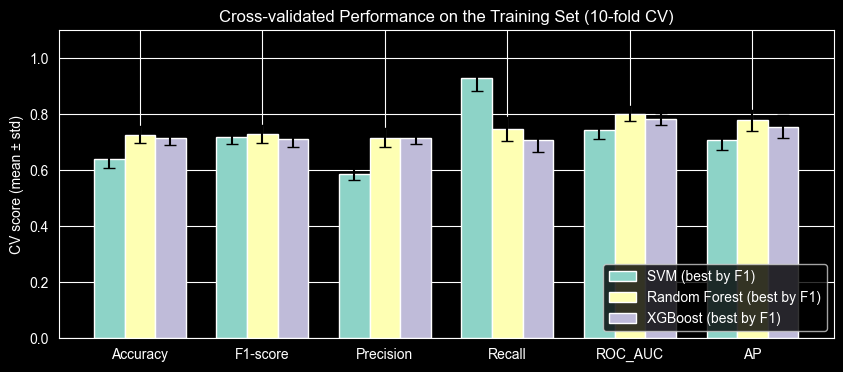

In [275]:
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.bar(x + width, means[labels[2]], width, yerr=stds[labels[2]], capsize=4, label=labels[2])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel('CV score (mean ± std)')
ax.set_title('Cross-validated Performance on the Training Set (10-fold CV)')
ax.legend(loc='lower right')
plt.show()

# Evaluation of Best Model on Test Set

From the results of cross-validation, we can see that the random forest model performed best in general, beating the two other models in every metric except precision and recall. Because of this, it was chosen as the model to perform the final evaluation on.

Now that we have the best model of the three, we can evaluate it on the test set. The function below gets the model's predicted probabilities of each song being in the popular category and the predicted binary classification of each song, then calculates and saves many performance metrics.

In [276]:
def evaluate_model(X_test, y_test, model):
    probabilities = model.predict_proba(X_test)[:, 1]

    predicted = model.predict(X_test)

    results = {
        'confusion_matrix': confusion_matrix(y_test, predicted),
        'accuracy': accuracy_score(y_test, predicted),
        'precision': precision_score(y_test, predicted, zero_division=0),
        'recall': recall_score(y_test, predicted, zero_division=0),
        'f1': f1_score(y_test, predicted, zero_division=0)
    }

    fpr, tpr, _ = roc_curve(y_test, probabilities)
    results['fpr'] = fpr
    results['tpr'] = tpr
    results['auc'] = auc(fpr, tpr)

    prc_precision, prc_recall, _ = precision_recall_curve(y_test, probabilities)
    results['prc_precision'] = prc_precision
    results['prc_recall'] = prc_recall
    results['ap'] = average_precision_score(y_test, probabilities)

    return results


Here, we use the function we just defined to evaluate our best model, the random forest model.

In [277]:
test_results = evaluate_model(X_test, y_test, rf_best_model)


The confusion matrix shows how many true/false positives and negatives the model gave as output for the test set.

In [278]:
cm_df = pd.DataFrame(
    test_results['confusion_matrix'],
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

print('Confusion Matrix (Test Set):')
cm_df

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,136,67
Actual 1,42,147


In [279]:
row_totals = cm_df.sum(axis=1)
rates_df = cm_df.div(row_totals, axis=0)

rates_df.columns = ['Predicted 0 (Rate)', 'Predicted 1 (Rate)']

print('Confusion Matrix Rates (Test Set):')
rates_df

Confusion Matrix Rates (Test Set):


,Predicted 0 (Rate),Predicted 1 (Rate)
Actual 0,0.669951,0.330049
Actual 1,0.222222,0.777778


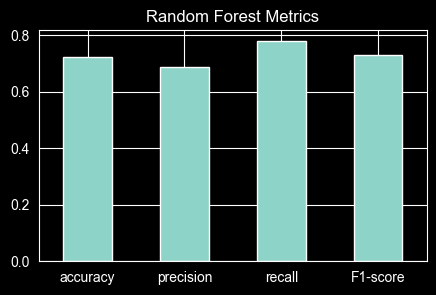

In [280]:
metrics = np.array([test_results['accuracy'], test_results['precision'], test_results['recall'], test_results['f1']])
index = ['accuracy', 'precision', 'recall', 'F1-score']
df_metrics = pd.DataFrame({'Random Forest': metrics}, index=index)
df_metrics.plot.bar(rot=0, figsize=(5, 3), legend=False, title='Random Forest Metrics')
plt.show()

The ROC (Receiving Operator Characteristic) curve shows how correctly our model identifies popular tracks. The closer AUC (area under the curve) is to 1, the more often the model correctly labels songs as popular, and the less often it incorrectly labels them as popular.

During testing, the model consistently achieved a reasonably high AUC of 0.75 - 0.8.

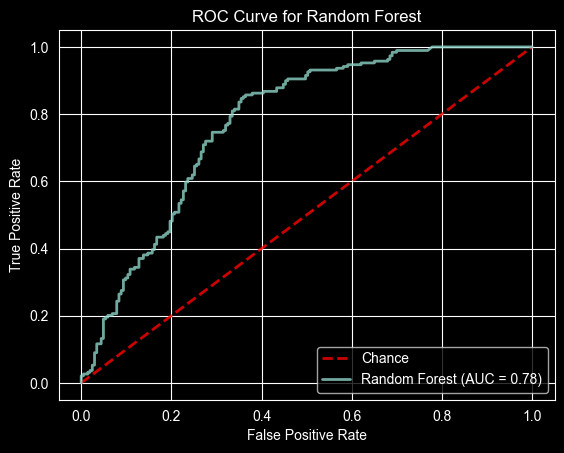

In [281]:
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
plt.plot(test_results['fpr'], test_results['tpr'], lw=2, label=f'Random Forest (AUC = {test_results['auc']:0.2f})', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc='lower right')
plt.show()

The precision-recall curve shows how well our model catches all of the popular tracks in the test set. The closer AP (average precision) is to 1, the more tracks it correctly labels as popular out of all popular tracks.

During testing, the model consistently achieved an AP of ~0.7, which means that the model will correctly label 70% of the popular tracks in a dataset as popular on average.

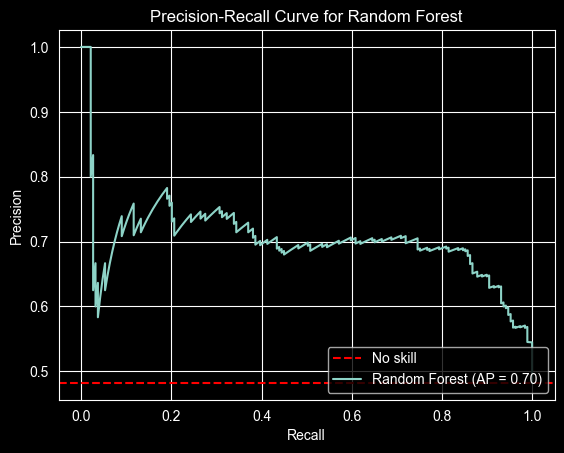

In [282]:
plt.axhline(y=y_test.mean(), color='red', linestyle='--', label='No skill')
plt.plot(test_results['prc_recall'], test_results['prc_precision'], label=f'Random Forest (AP = {test_results['ap']:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Random Forest')
plt.legend(loc='lower right')
plt.show()

# Random Forest Feature Importance

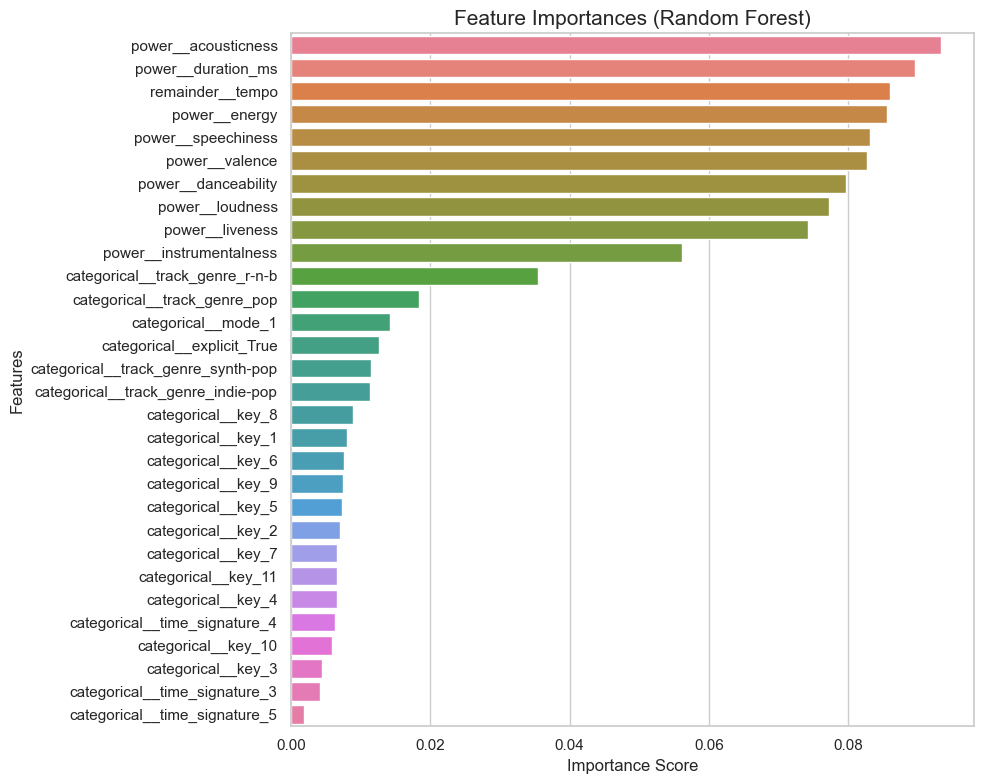

In [291]:
feature_names = rf_best_model.named_steps['preprocess'].get_feature_names_out()
importances = rf_best_model.named_steps['rf'].feature_importances_

feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_df.values,
            y=feature_importance_df.index,
            hue=feature_importance_df.index
            )

plt.title('Feature Importances (Random Forest)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

There are several interesting findings from these results:
- Audio characteristics (acousticness, tempo, energy) are what the model found to be the most influential.
- Duration was also very important, suggesting that listeners strongly prefer track lengths within a certain range.
- Following audio features, genre was a significant signal. R&B and pop were ranked above the others, which could imply a song is more likely to be popular if it fits in a mainstream genre.
- Music theory features like key, mode and time signature were ranked low, so were not defining characteristics of popularity.